# WELFake Fake News Detection

This notebook develops a supervised machine learning project for the WELFake dataset. The goal is to classify news articles as **Fake** or **Real** using their title and article text.

The work follows the CRISP-DM structure used in the course: Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, Feature Importance, and Conclusion.

Label convention used in this notebook:

- `0` means **Fake**
- `1` means **Real**


## 1. Business Understanding

Fake news detection is a binary classification task. Given the title and full text of a news article, the model should predict whether the article is fake or real.

The data mining goal is to build and compare supervised classifiers that can generalize to unseen articles. The main evaluation criteria are **Accuracy** and **F1-score**, supported by Precision, Recall, and Confusion Matrices.

The modeling strategy is intentionally simple and interpretable for the assignment:

- **Decision Tree** as a baseline model
- **Random Forest** as the main model
- **k-Nearest Neighbors (k-NN)** as an additional comparison model

No LLM is used for prediction or explanation in this version of the project.


## 2. Project Setup

Place `WELFake_Dataset.csv` in the same folder as this notebook. The code also includes common fallback paths for Google Colab.


In [1]:
from pathlib import Path
import csv

RANDOM_STATE = 42

candidate_paths = [
    Path("WELFake_Dataset.csv"),
    Path("data/WELFake_Dataset.csv"),
    Path("/content/WELFake_Dataset.csv"),
    Path("/content/data/WELFake_Dataset.csv"),
]

CSV_PATH = next((path for path in candidate_paths if path.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        "WELFake_Dataset.csv was not found. Place it next to this notebook or in a data/ folder."
    )

# The dataset contains long text fields, so increase the CSV field limit.
csv.field_size_limit(2147483647)

print(f"Using CSV path: {CSV_PATH}")
print(f"Random state: {RANDOM_STATE}")


Using CSV path: WELFake_Dataset.csv
Random state: 42


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass


## 3. Data Understanding

In this phase we load the raw dataset, inspect its columns, check the label distribution, and review basic data quality issues such as missing values and duplicates.


In [3]:
df_raw = pd.read_csv(CSV_PATH, engine="python", on_bad_lines="skip")

print("Raw dataset shape:", df_raw.shape)
print("Raw columns:", list(df_raw.columns))
display(df_raw.head())


Raw dataset shape: (72134, 4)
Raw columns: ['Unnamed: 0', 'title', 'text', 'label']


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...,No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of N...,"Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peac...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid",A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in ...,0
4,4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per sec and with a range o...",1


In [4]:
# Standardize column names and keep only the variables needed for this project.
df = df_raw.copy()
df.columns = df.columns.str.strip().str.lower()

required_columns = ["title", "text", "label"]
missing_required = [col for col in required_columns if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df = df[required_columns].copy()

print("Selected columns:", list(df.columns))
print("Shape after selecting required columns:", df.shape)
display(df.head())


Selected columns: ['title', 'text', 'label']
Shape after selecting required columns: (72134, 3)


,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...,No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of N...,"Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peac...",1
3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid",A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in ...,0
4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per sec and with a range o...",1


Missing values by column:


,missing_count
title,558
text,39
label,0


Duplicate rows before cleaning: 8456
Label distribution before cleaning:


,count
label,
0,35028
1,37106


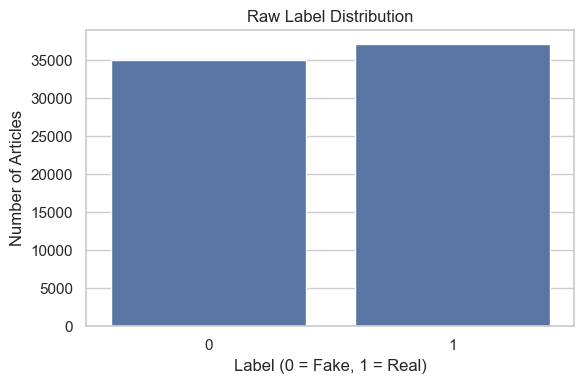

In [5]:
print("Missing values by column:")
display(df.isna().sum().to_frame("missing_count"))

print("Duplicate rows before cleaning:", df.duplicated().sum())

print("Label distribution before cleaning:")
label_counts = df["label"].value_counts(dropna=False).sort_index()
display(label_counts.to_frame("count"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label", order=[0, 1])
plt.title("Raw Label Distribution")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()


,title_length_words,text_length_words,combined_length_words
count,72134.00,72134.00,72134.00
mean,12.17,540.55,552.72
std,4.26,625.40,625.66
min,0.00,0.00,1.00
25%,9.00,227.00,239.00
50%,12.00,398.00,410.00
75%,14.00,667.00,679.00
max,72.00,24234.00,24243.00


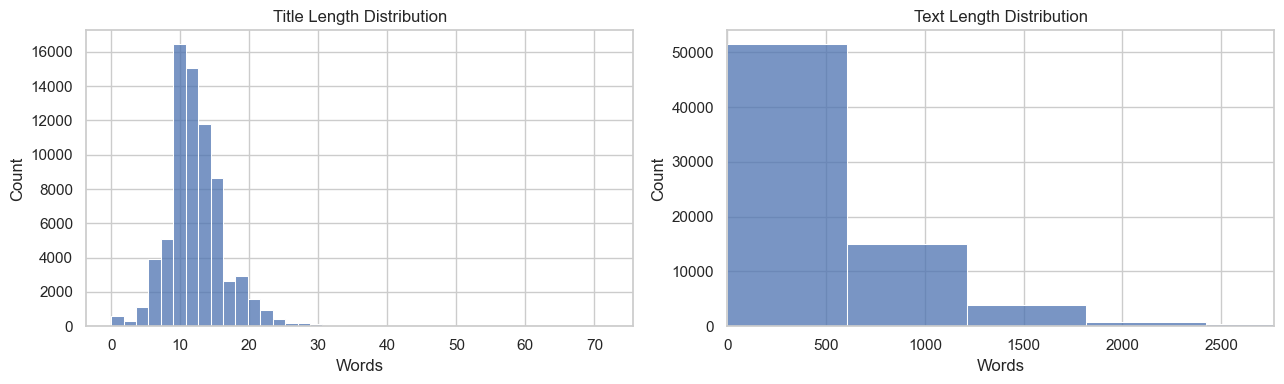

In [6]:
eda_lengths = pd.DataFrame({
    "title_length_words": df["title"].fillna("").astype(str).str.split().str.len(),
    "text_length_words": df["text"].fillna("").astype(str).str.split().str.len(),
})
eda_lengths["combined_length_words"] = (
    eda_lengths["title_length_words"] + eda_lengths["text_length_words"]
)

display(eda_lengths.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(eda_lengths["title_length_words"], bins=40, ax=axes[0])
axes[0].set_title("Title Length Distribution")
axes[0].set_xlabel("Words")

sns.histplot(eda_lengths["text_length_words"], bins=40, ax=axes[1])
axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Words")
axes[1].set_xlim(0, eda_lengths["text_length_words"].quantile(0.99))

plt.tight_layout()
plt.show()


## 4. Data Preparation

The preparation phase converts the raw records into a modeling dataset. The steps are:

- keep valid binary labels only;
- fill missing text fields with empty strings;
- remove rows without any usable title or text;
- remove exact duplicate records before the train/test split to reduce data leakage risk;
- create a combined text field and engineered numeric features.


In [7]:
def all_caps_ratio(value):
    """Return the share of alphabetic characters that are uppercase."""
    text = str(value)
    letters = [char for char in text if char.isalpha()]
    if not letters:
        return 0.0
    uppercase = sum(char.isupper() for char in letters)
    return uppercase / len(letters)


df_clean = df.copy()
rows_initial = len(df_clean)

# Keep valid binary labels only.
df_clean["label"] = pd.to_numeric(df_clean["label"], errors="coerce")
df_clean = df_clean[df_clean["label"].isin([0, 1])].copy()
df_clean["label"] = df_clean["label"].astype(int)
rows_after_valid_labels = len(df_clean)

# Handle missing text fields and remove records without usable text.
df_clean["title"] = df_clean["title"].fillna("").astype(str).str.strip()
df_clean["text"] = df_clean["text"].fillna("").astype(str).str.strip()
df_clean = df_clean[(df_clean["title"] != "") | (df_clean["text"] != "")].copy()
rows_after_non_empty_text = len(df_clean)

# Remove exact duplicate records before splitting to reduce leakage risk.
duplicates_removed = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
rows_after_dedup = len(df_clean)

# Derived attributes / feature engineering.
df_clean["combined_text"] = (df_clean["title"] + " " + df_clean["text"]).str.strip()
df_clean["title_length_words"] = df_clean["title"].str.split().str.len()
df_clean["text_length_words"] = df_clean["text"].str.split().str.len()
df_clean["combined_length_words"] = (
    df_clean["title_length_words"] + df_clean["text_length_words"]
)
df_clean["title_all_caps_ratio"] = df_clean["title"].apply(all_caps_ratio)
df_clean["text_all_caps_ratio"] = df_clean["text"].apply(all_caps_ratio)
df_clean["label_name"] = df_clean["label"].map({0: "Fake", 1: "Real"})

cleaning_summary = pd.DataFrame([
    {"step": "Initial selected rows", "rows": rows_initial},
    {"step": "After keeping valid binary labels", "rows": rows_after_valid_labels},
    {"step": "After removing rows without title or text", "rows": rows_after_non_empty_text},
    {"step": "After removing exact duplicates", "rows": rows_after_dedup},
])

print("Duplicates removed before split:", duplicates_removed)
display(cleaning_summary)
print("Clean dataset shape:", df_clean.shape)
display(df_clean.head())


Duplicates removed before split: 8458


,step,rows
0,Initial selected rows,72134
1,After keeping valid binary labels,72134
2,After removing rows without title or text,72134
3,After removing exact duplicates,63676


Clean dataset shape: (63676, 10)


,title,text,label,combined_text,title_length_words,text_length_words,combined_length_words,title_all_caps_ratio,text_all_caps_ratio,label_name
0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...,No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...,18,871,889,0.450980,0.041314,Real
1,,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?,0,8,8,0.000000,0.052632,Real
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of N...,"Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peace...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of N...,18,34,52,0.805310,0.028249,Real
3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid",A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in ...,0,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid A dozen po...",16,1321,1337,0.047619,0.038336,Fake
4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per sec and with a range o...",1,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice The RS-28 Sarmat mis...,16,329,345,0.213333,0.083845,Real


Label distribution after cleaning:


,count
label_name,
Fake,34790
Real,28886


,title_length_words,text_length_words,combined_length_words,title_all_caps_ratio,text_all_caps_ratio
count,63676.00,63676.0,63676.00,63676.00,63676.00
mean,11.89,542.3,554.19,0.19,0.05
std,3.97,610.4,610.75,0.16,0.04
min,0.00,0.0,1.00,0.00,0.00
25%,9.00,235.0,247.00,0.07,0.04
50%,11.00,403.0,414.00,0.16,0.04
75%,14.00,673.0,685.00,0.24,0.06
max,72.00,24234.0,24243.00,1.00,1.00


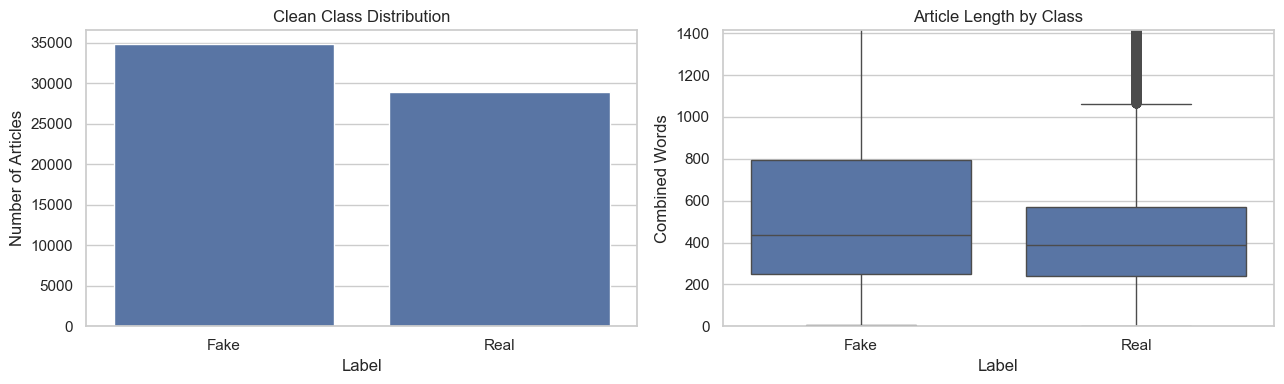

In [8]:
assert set(df_clean["label"].unique()) <= {0, 1}, "Only binary labels 0 and 1 are allowed."
assert df_clean["combined_text"].str.len().gt(0).all(), "Every row must have usable text."
assert df_clean.duplicated(subset=["title", "text", "label"]).sum() == 0, "Duplicates must be removed."

print("Label distribution after cleaning:")
display(df_clean["label_name"].value_counts().to_frame("count"))

display(
    df_clean[[
        "title_length_words",
        "text_length_words",
        "combined_length_words",
        "title_all_caps_ratio",
        "text_all_caps_ratio",
    ]].describe().round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df_clean, x="label_name", order=["Fake", "Real"], ax=axes[0])
axes[0].set_title("Clean Class Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Number of Articles")

sns.boxplot(data=df_clean, x="label_name", y="combined_length_words", order=["Fake", "Real"], ax=axes[1])
axes[1].set_title("Article Length by Class")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Combined Words")
axes[1].set_ylim(0, df_clean["combined_length_words"].quantile(0.95))

plt.tight_layout()
plt.show()


## 5. Modeling

The modeling phase transforms text into numerical TF-IDF features, scales the engineered numeric features, combines them into one sparse feature matrix, and trains three classifiers.

The split is stratified so that the train and test sets keep a similar Fake/Real distribution.


In [ ]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

X_text = df_clean["combined_text"]
numeric_feature_names = [
    "title_length_words",
    "text_length_words",
    "combined_length_words",
    "title_all_caps_ratio",
    "text_all_caps_ratio",
]
X_numeric = df_clean[numeric_feature_names]
y = df_clean["label"]

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text,
    X_numeric,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training rows:", len(y_train))
print("Test rows:", len(y_test))
print("Train label distribution:")
display(y_train.value_counts(normalize=True).sort_index().rename("share").to_frame())
print("Test label distribution:")
display(y_test.value_counts(normalize=True).sort_index().rename("share").to_frame())

overlap_count = len(set(y_train.index).intersection(set(y_test.index)))
print("Train/test overlapping rows:", overlap_count)
assert overlap_count == 0, "Training and test sets must not overlap."


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    stop_words="english",
    ngram_range=(1, 1),
)

X_train_tfidf = vectorizer.fit_transform(X_text_train)
X_test_tfidf = vectorizer.transform(X_text_test)

scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_num_train)
X_test_numeric_scaled = scaler.transform(X_num_test)

X_train_final = hstack([X_train_tfidf, X_train_numeric_scaled])
X_test_final = hstack([X_test_tfidf, X_test_numeric_scaled])

feature_names = list(vectorizer.get_feature_names_out()) + numeric_feature_names

print("Final training matrix shape:", X_train_final.shape)
print("Final test matrix shape:", X_test_final.shape)
print("Number of final features:", len(feature_names))

assert X_train_final.shape[1] == X_test_final.shape[1] == len(feature_names)


In [ ]:
decision_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Training Decision Tree baseline...")
decision_tree.fit(X_train_final, y_train)

print("Training Random Forest main model...")
random_forest.fit(X_train_final, y_train)

models = {
    "Decision Tree (baseline)": decision_tree,
    "Random Forest (main model)": random_forest,
}

print("Training complete.")


In [ ]:
# k-NN is computationally expensive on large sparse text data, so it is trained on a stratified sample.
KNN_TRAIN_SAMPLE_SIZE = min(10000, len(y_train))
knn_train_index = (
    y_train.to_frame("label")
    .groupby("label", group_keys=False)
    .sample(frac=KNN_TRAIN_SAMPLE_SIZE / len(y_train), random_state=RANDOM_STATE)
    .index
)
knn_positions = y_train.index.get_indexer(knn_train_index)

X_train_knn = X_train_final.tocsr()[knn_positions]
y_train_knn = y_train.loc[knn_train_index]

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="cosine",
    n_jobs=-1,
)

print("Training k-NN additional comparison model...")
print("k-NN training rows:", X_train_knn.shape[0])
knn.fit(X_train_knn, y_train_knn)

models["k-NN (additional comparison)"] = knn
print("All models are ready.")


## 6. Evaluation

This section evaluates each model on the held-out test set. The main metrics are Accuracy and F1-score, with Precision and Recall included for a more complete view of classification behavior.


In [ ]:
def evaluate_model(model, model_name, X_test, y_test):
    predictions = model.predict(X_test)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions),
        "recall": recall_score(y_test, predictions),
        "f1_score": f1_score(y_test, predictions),
        "predictions": predictions,
    }


evaluation_results = [
    evaluate_model(model, model_name, X_test_final, y_test)
    for model_name, model in models.items()
]

metrics_table = pd.DataFrame(evaluation_results).drop(columns="predictions")
metrics_table = metrics_table.sort_values("f1_score", ascending=False).reset_index(drop=True)
display(metrics_table.round(4))


In [ ]:
for result in evaluation_results:
    print("=" * 80)
    print(result["model"])
    print(classification_report(y_test, result["predictions"], target_names=["Fake", "Real"]))

    cm = confusion_matrix(y_test, result["predictions"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted Fake", "Predicted Real"],
        yticklabels=["Actual Fake", "Actual Real"],
    )
    plt.title(f"Confusion Matrix: {result['model']}")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()


## 7. Feature Importance

Random Forest provides feature importances that help identify which TF-IDF terms and engineered numeric variables contributed most to its decisions. This supports interpretation of the model, not only score reporting.


In [ ]:
rf_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": random_forest.feature_importances_,
}).sort_values("importance", ascending=False)

top_features = rf_importances.head(25)
display(top_features)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, y="feature", x="importance")
plt.title("Top 25 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Engineered numeric feature importances:")
display(
    rf_importances[rf_importances["feature"].isin(numeric_feature_names)]
    .sort_values("importance", ascending=False)
)


In [ ]:
print("Most important features in the Random Forest model:")
for rank, row in enumerate(top_features.head(10).itertuples(index=False), start=1):
    print(f"{rank}. {row.feature}: {row.importance:.4f}")

best_model_row = metrics_table.iloc[0]
print("\nBest model by F1-score:")
print(best_model_row.to_string())


## 8. Conclusion

The notebook compares a baseline Decision Tree, a main Random Forest model, and an additional k-NN model on the WELFake binary classification task.

The Random Forest is expected to be the strongest model because it combines many decision trees and can capture nonlinear patterns in both TF-IDF text features and engineered numeric variables. The k-NN model is included as a minimal additional comparison, but it is less suitable for this large high-dimensional text dataset and is trained on a stratified sample for runtime reasons.

The feature importance analysis gives a first interpretation of the Random Forest behavior by showing which words and engineered attributes are most discriminative. This makes the project more informative than reporting accuracy alone.


# WELFake Fake News Detection: Presentation and Q&A Guide

This guide is designed to help explain the project to the professor, connect it to the course slides, and justify the technical choices made in `FakeNewsDetect.ipynb`.

## 1. Project Overview

The project addresses a **supervised binary classification** problem: given a news article, the model predicts whether the article is **Fake** or **Real**.

Dataset: **WELFake Dataset**.

Main variables:

| Column | Meaning | Use in the project |
|---|---|---|
| `title` | Article title | Used to build textual and stylistic features |
| `text` | Full article text | Main content used by the model |
| `label` | Class label | Supervised target |

Label convention:

| Label | Class |
|---|---|
| `0` | Fake |
| `1` | Real |

Data mining objective:

> Train supervised models that learn from labeled news articles and classify unseen articles as Fake or Real.

Main metrics:

- **Accuracy**: overall percentage of correct predictions.
- **F1-score**: harmonic mean of precision and recall; useful to evaluate the balance between different types of errors.
- **Precision** and **Recall**: used to understand the kind of mistakes made by the model.
- **Confusion Matrix**: shows how many Fake/Real articles are classified correctly or incorrectly.

## 2. Alignment with CRISP-DM

The CRISP-DM slides explain that a data mining project is not only about applying an algorithm. It should follow a structured methodology. The notebook is organized according to this logic.

| CRISP-DM phase | Where it appears in the project | How to explain it orally |
|---|---|---|
| Business Understanding | Notebook section 1 | I define the problem: detecting fake news from title and text. |
| Data Understanding | Section 3 | I explore structure, missing values, duplicates, class distribution, and text lengths. |
| Data Preparation | Section 4 | I clean the data, create `combined_text`, remove duplicates, and build numeric features. |
| Modeling | Section 5 | I train Decision Tree, Random Forest, and k-NN. |
| Evaluation | Section 6 | I compare the models using Accuracy, Precision, Recall, F1-score, and confusion matrices. |
| Deployment | Not implemented | It is not required because this is an academic/prototype project, not a production system. |

Useful sentence:

> I followed CRISP-DM to avoid focusing only on the algorithm. First I defined the problem, then I understood and prepared the data, and finally I trained and evaluated the models.

## 3. Business Understanding

The business/data mining question is:

> Can we use machine learning techniques to automatically distinguish fake news articles from real ones using textual content and stylistic characteristics?

The problem is supervised because every article has a known label (`0` or `1`), so the model can learn from already classified examples.

Success criteria:

- obtain good performance on the test set;
- compare more than one model, not only Random Forest;
- keep the project explainable;
- interpret, at least partially, which features contribute to the decisions.

## 4. Data Understanding

The initial dataset contains:

- **72134 rows**;
- original columns including `title`, `text`, and `label`;
- some missing values in `title` and `text`;
- exact duplicate rows.

The notebook checks:

- dataset shape;
- column names;
- missing values;
- duplicates;
- label distribution;
- title and text lengths.

Why this matters:

> The Data Understanding slides emphasize data quality. If I do not first understand missing values, duplicates, and class distribution, I risk building a model with unreliable results.

## 5. Data Preparation

The preparation phase is central because machine learning algorithms cannot work directly with raw text. Text must be transformed into numbers.

Main steps:

1. Select the columns `title`, `text`, and `label`.
2. Convert the label into a numeric value.
3. Handle missing values:
   - missing `title` and `text` values are replaced with empty strings;
   - only rows with at least one usable title or text are kept.
4. Remove exact duplicates **before the train/test split**.
5. Create `combined_text` by joining title and text.
6. Create numeric features:
   - `title_length_words`;
   - `text_length_words`;
   - `combined_length_words`;
   - `title_all_caps_ratio`;
   - `text_all_caps_ratio`.

Real numbers from the notebook:

| Step | Rows |
|---|---:|
| Initial dataset | 72134 |
| After keeping valid labels | 72134 |
| After removing rows without useful text | 72134 |
| After removing duplicates | 63676 |

Duplicates removed:

```text
8458
```

### Why remove duplicates before the split?

If the same article appeared both in the training set and in the test set, the model could look very good simply because it had already seen that example or an identical duplicate. This is called **data leakage**.

Useful sentence:

> I removed duplicates before the split to make the test-set evaluation more credible. The test set should simulate unseen data.

## 6. NLP Feature Extraction

The professor asked how to extract information from natural language content. The technical answer in this project is **TF-IDF**.

### Why TF-IDF?

TF-IDF means **Term Frequency - Inverse Document Frequency**.

In simple terms:

- it gives higher weight to terms that are important in a document;
- it reduces the weight of terms that are too common;
- it transforms text into a numeric matrix that ML algorithms can use.

In the project:

- `combined_text` is transformed using `TfidfVectorizer`;
- the maximum number of terms is `5000`;
- English stop words are removed;
- unigrams are used, meaning single words.

Useful sentence:

> TF-IDF does not understand language like a human, but it represents article content through numeric features based on discriminative terms.

### Why add numeric features?

In addition to lexical content, stylistic signals can be useful:

- very long titles;
- very short or very long texts;
- use of uppercase letters;
- relationship between title and text length.

These features do not replace TF-IDF. They complement it.

Useful sentence:

> I combined textual and stylistic features: TF-IDF captures which words appear, while numeric features describe how the article is written.

## 7. Modeling

The project uses three models:

| Model | Role | Why it was chosen |
|---|---|---|
| Decision Tree | Baseline | Simple, interpretable, and coherent with the introductory slides. |
| Random Forest | Main model | More robust than a single tree; reduces overfitting by aggregating many trees. |
| k-NN | Additional comparison | A model covered in the slides; useful as a comparison, although less suitable for sparse/high-dimensional text data. |

### Why Decision Tree as a baseline?

A baseline is a simple reference model. If a more complex model does not outperform the baseline, the added complexity is not justified.

Useful sentence:

> I used the Decision Tree as a baseline to have a simple and interpretable comparison point.

### Why Random Forest as the main model?

Random Forest combines many Decision Trees. Each tree sees a different part of the data/features, and the final result is aggregated.

Advantages:

- it often generalizes better than a single tree;
- it reduces the risk of overfitting;
- it works well with numeric and transformed text features;
- it provides feature importance.

Useful sentence:

> Random Forest is the main model because it preserves some interpretability through feature importance while being more robust than a single Decision Tree.

### Why k-NN only as a comparison?

k-NN classifies a new point by looking at the closest examples. However, with TF-IDF text data, the feature space is very large and sparse.

For this reason:

- it is less efficient;
- it can suffer in high-dimensional spaces;
- it was trained on a stratified sample to keep runtime manageable.

Useful sentence:

> I included k-NN to avoid limiting the project to Random Forest and to compare an instance-based model with tree-based models. However, I expected lower performance because TF-IDF text creates a high-dimensional feature space.

## 8. Evaluation

The dataset is split into:

- **80% training set**;
- **20% test set**;
- stratified split;
- `RANDOM_STATE = 42` for reproducibility.

The stratified split keeps a similar Fake/Real distribution in both training and test sets.

Real results:

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Random Forest | 0.9598 | 0.9530 | 0.9586 | 0.9558 |
| Decision Tree | 0.9388 | 0.9304 | 0.9351 | 0.9328 |
| k-NN | 0.8349 | 0.7656 | 0.9166 | 0.8343 |

Conclusion:

> Random Forest is the best model according to F1-score and Accuracy. Decision Tree performs well but is less robust. k-NN performs worse, probably because TF-IDF features are sparse and high-dimensional.

## 9. Feature Importance

Random Forest can estimate which features contributed the most to its decisions.

Top features from the notebook:

| Rank | Feature | Importance |
|---:|---|---:|
| 1 | `title_all_caps_ratio` | 0.0679 |
| 2 | `reuters` | 0.0646 |
| 3 | `said` | 0.0403 |
| 4 | `image` | 0.0256 |
| 5 | `video` | 0.0199 |
| 6 | `featured` | 0.0169 |
| 7 | `title_length_words` | 0.0146 |
| 8 | `getty` | 0.0100 |
| 9 | `breitbart` | 0.0097 |
| 10 | `york` | 0.0096 |

Interpretation:

- `title_all_caps_ratio`: captures how much the title uses uppercase letters; it may reflect a more sensationalistic style.
- `reuters`, `said`, `york`: may reflect journalistic style or mainstream sources.
- `image`, `video`, `featured`, `getty`, `breitbart`: may indicate sources, formats, or editorial patterns.
- `title_length_words`: shows that title structure also contributes.

Important note:

> Feature importance does not mean causality. If `reuters` is important, it does not mean that the word makes an article true; it means that, in this dataset, the word helps the model distinguish the classes.

## 10. Why Not Use a Neural Network / MLP?

The slides include Neural Networks and `MLPClassifier`, but it is not necessary to use every model covered in the course.

Reasons for not using it in this project:

- the proposal approved by the professor was centered on classical ML models;
- Random Forest, Decision Tree, and k-NN are present in the Modeling/Evaluation slides;
- the goal is to explain the pipeline, NLP preprocessing, evaluation, and interpretability well;
- an MLP would require more tuning and more attention to scaling, convergence, and overfitting;
- with high-dimensional TF-IDF, an MLP can become more expensive and less straightforward to defend orally;
- Random Forest provides feature importance, which is easier to present.

Short answer if the professor asks:

> I decided not to use a neural network to keep the project more interpretable and coherent with the initial proposal. For this assignment, I wanted to focus on CRISP-DM, NLP preprocessing, comparison between classical models, and interpretation of the results.

## 11. Project Limitations

Main limitations to state confidently:

1. **TF-IDF does not understand deep semantics**  
   It represents text through weighted frequencies, but it does not understand irony, context, intention, or deeper meaning.

2. **Possible dataset bias**  
   The model may learn patterns related to sources, historical period, or editorial style, not only news truthfulness.

3. **Feature importance is not causality**  
   An important feature helps the model, but it does not prove a causal relationship.

4. **k-NN is not ideal for TF-IDF**  
   Textual features are sparse and high-dimensional, so the distance concept becomes less effective.

5. **No deployment**  
   The project stops at experimental evaluation and does not create a production application.

6. **No external validation**  
   The model is evaluated on an internal dataset split, not on a completely different dataset.

Useful sentence:

> The most important limitation is that the model may learn dataset-specific patterns, such as sources and writing style, rather than a general concept of news truthfulness.

## 12. Oral Presentation Outline

### 5-7 minute version

1. **Problem**
   - Fake/Real classification.
   - WELFake dataset.
   - Label `0 = Fake`, `1 = Real`.

2. **CRISP-DM**
   - I followed Business Understanding, Data Understanding, Data Preparation, Modeling, and Evaluation.
   - Deployment is not included because this is an academic project.

3. **Data Understanding**
   - Check columns, missing values, duplicates, class distribution.
   - Initial dataset: 72134 rows.

4. **Data Preparation**
   - Text cleaning.
   - Duplicate removal: 8458.
   - Final dataset: 63676 rows.
   - `combined_text`, TF-IDF, stylistic features.

5. **Modeling**
   - Decision Tree baseline.
   - Random Forest main model.
   - k-NN additional comparison.

6. **Evaluation**
   - Random Forest is best: Accuracy 0.9598, F1 0.9558.
   - Decision Tree is good but lower.
   - k-NN is worse because of high dimensionality.

7. **Interpretation and limitations**
   - Feature importance.
   - Be careful with bias and non-causal interpretation.

## 13. Likely Questions and Prepared Answers

### 1. Why did you use TF-IDF?

Because the dataset is textual and ML algorithms need numeric input. TF-IDF transforms text into numeric features by giving more weight to discriminative terms and less weight to very common words.

Short answer:

> TF-IDF is a simple, effective, and explainable way to transform text into numeric features.

### 2. Does the model really understand natural language?

Not in the human sense. With TF-IDF, the model does not understand deep semantics, irony, or context. It learns statistical patterns in terms and writing style.

Short answer:

> No, it does not understand language like a human. It extracts numeric patterns from text.

### 3. Why did you combine `title` and `text` into `combined_text`?

To use both the article title and the full content in the same TF-IDF representation. The title can contain strong signals, while the full text provides more context.

Short answer:

> I combined title and text to avoid losing useful information from either part.

### 4. Why did you add features such as length and all-caps ratio?

Because style can be informative in addition to words. Some fake news articles may use more sensationalistic titles, uppercase letters, or different length patterns.

Short answer:

> These are stylistic features that complement TF-IDF lexical features.

### 5. Why did you remove duplicates?

To avoid data leakage. If a duplicate appears in both train and test sets, the model may look better simply because it has already seen almost the same example.

Short answer:

> I removed duplicates before the split to make the test set more realistic and independent.

### 6. Why use a stratified train/test split?

To keep similar proportions of Fake and Real articles in both training and test sets. This makes the comparison more reliable.

Short answer:

> Stratified splitting preserves the class distribution.

### 7. Why use Accuracy and F1-score?

Accuracy shows the overall proportion of correct predictions. F1-score balances precision and recall, so it is useful when I want to consider both types of classification errors.

Short answer:

> Accuracy gives a global view, while F1-score better evaluates the balance between precision and recall.

### 8. Why does Random Forest perform better than Decision Tree?

A single Decision Tree can overfit. Random Forest combines many trees and usually generalizes better.

Short answer:

> Random Forest reduces the variance of a single tree by aggregating many Decision Trees.

### 9. Why does k-NN perform worse?

Because k-NN depends on distances between examples. With TF-IDF, the feature space is very large and sparse, so distance can become less informative.

Short answer:

> k-NN suffers in high-dimensional and sparse text spaces.

### 10. Why did you not use a neural network?

Because the goal was to build an interpretable project coherent with the approved proposal. Decision Tree, Random Forest, and k-NN are also models covered in the Modeling/Evaluation slides.

Short answer:

> It was not necessary to add complexity. I preferred models that are easier to explain and defend.

### 11. What does feature importance mean?

It indicates how much a feature contributed to the decisions of the Random Forest. It does not mean that the feature causally determines the class.

Short answer:

> Feature importance measures predictive usefulness, not causality.

### 12. Why is `reuters` an important feature?

Probably because, in the dataset, the word `reuters` often appears in articles with a specific source or journalistic style. The model uses it as a statistical signal.

Short answer:

> `reuters` may capture a source or style pattern, but it must be interpreted carefully.

### 13. Is there a risk that the model learns the source instead of truthfulness?

Yes, and this is one of the main limitations. Some important words may represent sources or editorial formats rather than the general concept of fake news.

Short answer:

> Yes, and for this reason I state source bias as a limitation of the project.

### 14. Did removing duplicates lower the performance?

It may lower the performance compared to an evaluation with duplicates, but it makes the result more credible. A test set with duplicates would be too easy.

Short answer:

> Even if it may reduce the score, it makes the evaluation more correct.

### 15. Why did you not use cross-validation?

To keep the project simple and manageable. I used a reproducible stratified split with a separate test set. A possible extension would be adding cross-validation.

Short answer:

> For this assignment, I used a separate test set; cross-validation would be a good extension.

### 16. Which model is the best?

Random Forest, because it has the highest F1-score:

```text
F1-score = 0.9558
Accuracy = 0.9598
```

Short answer:

> Random Forest is the best model according to F1-score and Accuracy.

### 17. What is the most important limitation of the project?

The model may learn patterns specific to the dataset, such as sources, style, or historical period, instead of a general definition of truthfulness.

Short answer:

> The main limitation is generalization outside the WELFake dataset.

### 18. How would you improve the project in the future?

Possible extensions:

- cross-validation;
- error analysis;
- comparison with Logistic Regression or Linear SVM;
- validation on another dataset;
- use of embeddings or transformers;
- more advanced explainability, for example SHAP.

Short answer:

> The first improvement would be testing the model on an external dataset to evaluate generalization.

### 19. Why did you choose a maximum of 5000 TF-IDF features?

To limit dimensionality and runtime while keeping a sufficiently rich vocabulary. With too many features, the model can become slower and harder to manage.

Short answer:

> It is a compromise between information, efficiency, and computational simplicity.

### 20. What does the confusion matrix represent?

It shows how many Fake and Real examples were classified correctly or incorrectly. It helps understand whether the model more often predicts Fake as Real or Real as Fake.

Short answer:

> The confusion matrix shows the type of errors, not only the number of errors.

## 14. Quick Link to the Slides

| Lecture/slide topic | Concept | Connection to the project |
|---|---|---|
| 01 CRISP-DM | Data mining project lifecycle | Full notebook structure |
| 02 Business Understanding | Objective and metrics | Fake/Real classification, Accuracy and F1 |
| 03 Data Understanding | Data quality | Missing values, duplicates, class distribution |
| 04 Data Preparation | Cleaning and feature engineering | `combined_text`, TF-IDF, numeric features |
| 05 Neural Networks | MLP and model complexity | Not used; choice justified by interpretability |
| 06 Modeling/Evaluation | Decision Tree, Random Forest, k-NN, evaluation | Exactly the three models used and compared |

## 15. Short Final Conclusion for the Professor

> In this project, I followed the CRISP-DM process to build a supervised classifier on an NLP dataset. I transformed the text using TF-IDF, added some stylistic features, removed duplicates to avoid leakage, and compared three models: Decision Tree, Random Forest, and k-NN. Random Forest achieved the best result with an F1-score of 0.9558. The result is good, but it must be interpreted carefully because the model may learn patterns related to sources and writing style rather than a deep understanding of news truthfulness.